# Hyperparameter Search Analysis

Generator: `gpt-5.4-nano` · Evaluator: `gpt-5.4-mini` · Cases: `pl_age`, `pl_personal_rights`

| Parameter | Abbrev. | Values |
|---|---|---|
| `max_refinement_rounds` | `maxrr` | 2, 3, 4 |
| `min_refinement_rounds` | `minrr` | 1, 2 |
| `max_data_refinement_rounds` | `maxdrr` | 2, 3, 4 |
| `min_data_refinement_rounds` | `mindrr` | 1, 2 |
| `data_assessment_num_examples` | `dane` | 1, 2, 3 |

In [30]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

EVAL_DIR = Path("outputs/evaluation/multirun/gpt-5.4-mini/gpt-5.4-nano")
FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PARAMS = ["maxrr", "minrr", "maxdrr", "mindrr", "dane"]
PLOT_PARAMS = ["minrr", "maxrr", "mindrr", "maxdrr", "dane"]
PARAM_LABELS = {
    "maxrr": "max refinement\nrounds",
    "minrr": "min refinement\nrounds",
    "maxdrr": "max data\nrefinement rounds",
    "mindrr": "min data\nrefinement rounds",
    "dane": "data assessment\nexamples",
}
CASES = ["pl_age", "pl_personal_rights", "pl_medical_errors"]
PARAM_RE = re.compile(r"maxrr_(\d+)_minrr_(\d+)_maxdrr_(\d+)_mindrr_(\d+)_dane_(\d+)")

sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [31]:
records = []
for path in sorted(EVAL_DIR.glob("**/evaluation.json")):
    m = PARAM_RE.match(path.parent.name)
    if not m:
        continue
    params = dict(zip(PARAMS, map(int, m.groups())))
    ed = json.loads(path.read_text())
    cov, hc = [], []
    for schema in ed["evaluations"]:
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
                hc.append(expert["high_confidence"] / t)
    records.append({
        "case": path.parent.parent.name,
        **params,
        "coverage_rate": float(np.mean(cov)),
        "high_conf_rate": float(np.mean(hc)),
    })

df = pd.DataFrame(records)
print(f"{len(df)} runs · {df['case'].nunique()} cases · {df[PARAMS].drop_duplicates().shape[0]} unique configs")

324 runs · 3 cases · 108 unique configs


## Best parameter set

In [32]:
ranked = (
    df.groupby(PARAMS)[["coverage_rate", "high_conf_rate"]]
    .mean()
    .reset_index()
    .sort_values(["coverage_rate", "high_conf_rate"], ascending=False)
    .reset_index(drop=True)
)
ranked.index += 1

display(ranked.head(10).style
    .format({"coverage_rate": "{:.3f}", "high_conf_rate": "{:.3f}"})
    .highlight_max(subset=["coverage_rate", "high_conf_rate"], color="#c6efce")
)

best = ranked.iloc[0]
print("\nBest configuration:")
for p in PARAMS:
    print(f"  {p} = {int(best[p])}")
print(f"  coverage_rate  = {best['coverage_rate']:.4f}")
print(f"  high_conf_rate = {best['high_conf_rate']:.4f}")

,maxrr,minrr,maxdrr,mindrr,dane,coverage_rate,high_conf_rate
1,3,2,4,2,1,0.796,0.730
2,2,1,3,1,3,0.792,0.689
3,3,2,4,1,1,0.792,0.718
4,3,2,3,1,3,0.791,0.663
5,3,1,4,1,1,0.790,0.723
6,3,1,4,2,1,0.790,0.723
7,3,1,3,2,3,0.789,0.663
8,3,2,3,2,3,0.789,0.663
9,3,1,3,1,3,0.784,0.689
10,3,2,2,1,1,0.775,0.686



Best configuration:
  maxrr = 3
  minrr = 2
  maxdrr = 4
  mindrr = 2
  dane = 1
  coverage_rate  = 0.7963
  high_conf_rate = 0.7297


## Parameter influence on coverage rate

Saved: outputs/figures/param_influence_coverage.pdf


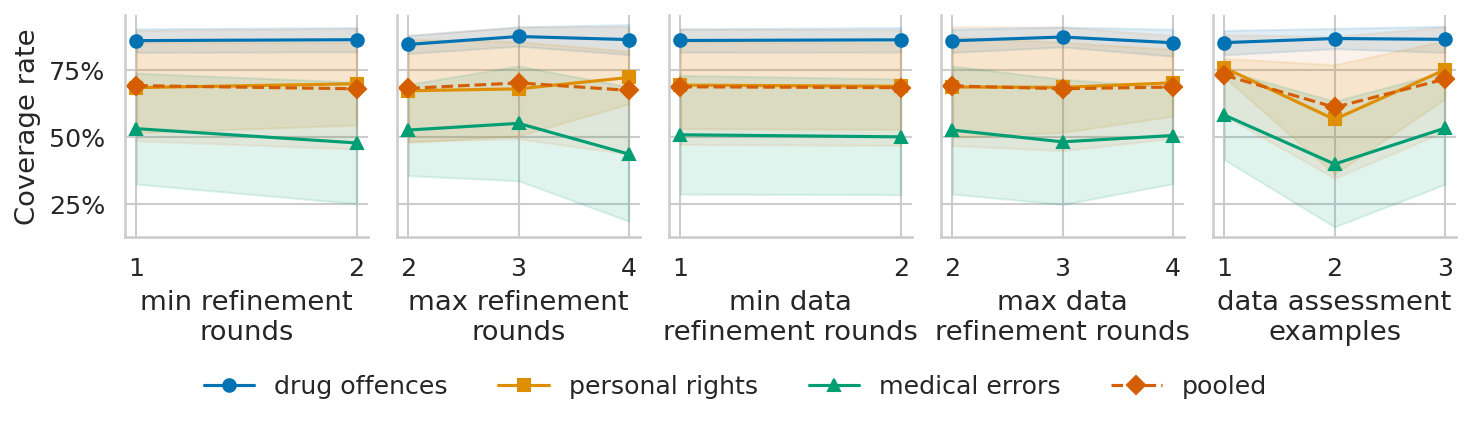


Marginal effect (pooled, range of means):
  minrr    Δ=0.0118 (1.2 pp)
  maxrr    Δ=0.0278 (2.8 pp)
  mindrr   Δ=0.0033 (0.3 pp)
  maxdrr   Δ=0.0105 (1.0 pp)
  dane     Δ=0.1201 (12.0 pp)


In [33]:
CASE_NAMES = {
    "pl_age": "drug offences",
    "pl_medical_errors": "medical errors",
    "pl_personal_rights": "personal rights",
}


def fmt_label(name: str) -> str:
    return CASE_NAMES.get(name, re.sub(r"^[a-z]{2}_", "", name).replace("_", " "))

all_series = CASES + ["pooled"]
markers    = ["o", "s", "^", "D", "v"]
palette    = sns.color_palette("colorblind", n_colors=len(all_series))
color_map  = {c: palette[i] for i, c in enumerate(all_series)}
marker_map = {c: markers[i % len(markers)] for i, c in enumerate(all_series)}

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, 5, figsize=(10, 2.6), sharey=True)

for ax, param in zip(axes, PLOT_PARAMS):
    for case in CASES:
        sub = df[df["case"] == case]
        s = sub.groupby(param)["coverage_rate"].agg(["mean", "std"]).reset_index()
        ax.plot(s[param], s["mean"], marker=marker_map[case], color=color_map[case],
                label=fmt_label(case))
        ax.fill_between(s[param], s["mean"] - s["std"].fillna(0),
                        s["mean"] + s["std"].fillna(0), color=color_map[case], alpha=0.12)

    s_pool = df.groupby(param)["coverage_rate"].agg(["mean", "std"]).reset_index()
    ax.plot(s_pool[param], s_pool["mean"], marker=marker_map["pooled"], color=color_map["pooled"],
            linestyle="--", label="pooled")
    ax.fill_between(s_pool[param], s_pool["mean"] - s_pool["std"].fillna(0),
                    s_pool["mean"] + s_pool["std"].fillna(0), color=color_map["pooled"], alpha=0.08)

    ax.set_xlabel(PARAM_LABELS[param])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_ylabel("Coverage rate")

sns.despine(fig=fig)
fig.tight_layout()
fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="lower center",
    ncol=len(all_series),
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
)

out = FIGURES_DIR / "param_influence_coverage.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

print("\nMarginal effect (pooled, range of means):")
for param in PLOT_PARAMS:
    means = df.groupby(param)["coverage_rate"].mean()
    delta = means.max() - means.min()
    print(f"  {param:<8} Δ={delta:.4f} ({delta*100:.1f} pp)")